<div style="max-width:980px;margin:28px auto 48px auto;background:linear-gradient(180deg,#fffdfc 0%,#ffffff 100%);border:1px solid #e5e7eb;border-radius:26px;box-shadow:0 18px 50px rgba(15,23,42,0.10);overflow:hidden;font-family:'Inter','Segoe UI',Arial,sans-serif;color:#0f172a;">
<div style="height:12px;background:linear-gradient(90deg,#7f1d1d 0%,#b91c1c 28%,#ea580c 58%,#1d4ed8 100%);"></div>
<div style="padding:58px 84px 72px 84px;">
<div style="text-align:center;">
<div style="font-size:18px;font-weight:700;letter-spacing:0.18em;text-transform:uppercase;color:#991b1b;margin-bottom:18px;">COMP8221 Advanced Machine Learning</div>
<div style="font-size:54px;line-height:1.10;font-weight:900;letter-spacing:-0.04em;margin-bottom:14px;">Cold Diffusion for Flower Image Generation</div>
<div style="font-size:30px;line-height:1.25;font-weight:700;color:#1e293b;max-width:760px;margin:0 auto 18px auto;">Reversing Deterministic Blur from Scratch with a Time-Conditioned U-Net</div>
<div style="display:inline-block;padding:10px 18px;background:linear-gradient(90deg,#fff1f2 0%,#fff7ed 100%);border:1px solid #fecdd3;border-radius:999px;font-size:15px;font-weight:700;color:#9f1239;margin-top:8px;">A Non-Standard Diffusion Variant for Oxford-102 Flowers</div>
</div>
<div style="width:100%;height:1px;background:linear-gradient(90deg,rgba(127,29,29,0) 0%,rgba(127,29,29,0.35) 18%,rgba(30,41,59,0.35) 50%,rgba(29,78,216,0.25) 82%,rgba(29,78,216,0) 100%);margin:34px 0 40px 0;"></div>
<table style="width:100%;border-collapse:separate;border-spacing:0;">
<tr>
<td style="width:58%;vertical-align:top;padding-right:18px;">
<div style="font-size:18px;font-weight:800;color:#111827;margin-bottom:14px;">Assignment Overview</div>
<table style="width:100%;border-collapse:collapse;font-size:15px;line-height:1.8;">
<tr><td style="font-weight:800;color:#7c2d12;padding:4px 10px 4px 0;width:170px;">Assessment</td><td style="padding:4px 0;">Assignment 1</td></tr>
<tr><td style="font-weight:800;color:#7c2d12;padding:4px 10px 4px 0;">Session</td><td style="padding:4px 0;">Session 1, 2026</td></tr>
<tr><td style="font-weight:800;color:#7c2d12;padding:4px 10px 4px 0;">Student Name</td><td style="padding:4px 0;">Alireza Yegane</td></tr>
<tr><td style="font-weight:800;color:#7c2d12;padding:4px 10px 4px 0;">Student ID</td><td style="padding:4px 0;">60957107</td></tr>
<tr><td style="font-weight:800;color:#7c2d12;padding:4px 10px 4px 0;">Project</td><td style="padding:4px 0;">Cold Diffusion on Oxford-102 Flowers</td></tr>
<tr><td style="font-weight:800;color:#7c2d12;padding:4px 10px 4px 0;">Date</td><td style="padding:4px 0;">4 April 2026</td></tr>
</table>
</td>
<td style="width:42%;vertical-align:top;">
<div style="width:270px;margin:0 auto;background:linear-gradient(180deg,#ffffff 0%,#fafaf9 100%);border:1px solid #e5e7eb;border-radius:22px;padding:22px 18px 18px 18px;text-align:center;box-shadow:0 10px 28px rgba(15,23,42,0.06);">
<div style="height:120px;display:flex;align-items:center;justify-content:center;margin-bottom:14px;">
<img src="mq_logo.png" style="width:112px;height:112px;object-fit:contain;display:block;">
</div>
<div style="font-size:22px;font-weight:900;letter-spacing:0.04em;color:#111827;">MACQUARIE</div>
<div style="font-size:18px;color:#374151;margin-top:2px;">University</div>
<div style="font-size:11px;letter-spacing:0.24em;text-transform:uppercase;color:#6b7280;margin-top:8px;">Sydney Australia</div>
</div>
</td>
</tr>
</table>
<div style="margin-top:34px;display:grid;grid-template-columns:repeat(3,1fr);gap:14px;">
<div style="background:#fff7ed;border:1px solid #fed7aa;border-radius:16px;padding:14px 16px;"><div style="font-size:11px;text-transform:uppercase;letter-spacing:0.12em;color:#9a3412;font-weight:800;">Dataset</div><div style="font-size:15px;font-weight:700;color:#111827;margin-top:6px;">Oxford-102 Flowers</div></div>
<div style="background:#fef2f2;border:1px solid #fecaca;border-radius:16px;padding:14px 16px;"><div style="font-size:11px;text-transform:uppercase;letter-spacing:0.12em;color:#991b1b;font-weight:800;">Core Model</div><div style="font-size:15px;font-weight:700;color:#111827;margin-top:6px;">Time-Conditioned U-Net</div></div>
<div style="background:#eff6ff;border:1px solid #bfdbfe;border-radius:16px;padding:14px 16px;"><div style="font-size:11px;text-transform:uppercase;letter-spacing:0.12em;color:#1d4ed8;font-weight:800;">Primary Metric</div><div style="font-size:15px;font-weight:700;color:#111827;margin-top:6px;">FID</div></div>
</div>
</div>
</div>

## 1. Objective

This notebook presents the final qualitative and quantitative results for the project in a polished, submission-ready format.


## 2. Dataset and Preprocessing

- Dataset: Oxford-102 Flowers  
- Official split loaded from `setid.mat`  
- Resolution: **64x64**  
- Normalization: **[-1, 1]**


## 3. Method Overview

- Deterministic Gaussian blur degradation  
- Time-conditioned U-Net  
- L1 loss on clean-image prediction  
- EMA checkpoint for evaluation


In [1]:
from pathlib import Path
import base64
import pandas as pd
from IPython.display import HTML, display

def resolve_project_root():
    cwd = Path.cwd().resolve()
    for root in [cwd, cwd.parent]:
        if (root / "outputs" / "report_figures").exists():
            return root
    return cwd

project_root = resolve_project_root()
report_dir = project_root / "outputs" / "report_figures"

def img_uri(path: Path) -> str:
    data = base64.b64encode(path.read_bytes()).decode("utf-8")
    return f"data:image/png;base64,{data}"

def render_cards(title, subtitle, items, columns=2):
    cards = []
    for item in items:
        path = report_dir / item["file"]
        if path.exists():
            image_html = f'<img src="{img_uri(path)}" style="width:100%;display:block;border-radius:16px;">'
            status_html = ""
        else:
            image_html = f'''
            <div style="height:300px;display:flex;align-items:center;justify-content:center;background:#f8fafc;border-radius:16px;color:#64748b;font-weight:700;text-align:center;padding:12px;">
                Missing asset<br>{item["file"]}
            </div>
            '''
            status_html = '<div style="margin-top:10px;color:#b91c1c;font-size:12px;font-weight:700;">Asset not found</div>'

        cards.append(f'''
        <div style="background:#ffffff;border:1px solid #e2e8f0;border-radius:22px;padding:16px;box-shadow:0 10px 28px rgba(15,23,42,0.08);">
            {image_html}
            <div style="font-size:18px;font-weight:800;color:#0f172a;margin-top:14px;">{item["title"]}</div>
            <div style="font-size:13px;line-height:1.7;color:#475569;margin-top:8px;">{item["caption"]}</div>
            {status_html}
        </div>
        ''')

    html = f'''
    <div style="max-width:1240px;margin:0 auto 28px auto;font-family:Arial,Helvetica,sans-serif;">
        <div style="font-size:28px;font-weight:900;color:#0f172a;margin-bottom:8px;">{title}</div>
        <div style="font-size:14px;line-height:1.7;color:#475569;margin-bottom:18px;">{subtitle}</div>
        <div style="display:grid;grid-template-columns:repeat({columns}, minmax(320px, 1fr));gap:24px;">
            {''.join(cards)}
        </div>
    </div>
    '''
    display(HTML(html))

def render_table(csv_name, title, subtitle):
    path = report_dir / csv_name
    display(HTML(f'''
    <div style="max-width:1240px;margin:0 auto 12px auto;font-family:Arial,Helvetica,sans-serif;">
        <div style="font-size:28px;font-weight:900;color:#0f172a;margin-bottom:8px;">{title}</div>
        <div style="font-size:14px;line-height:1.7;color:#475569;margin-bottom:18px;">{subtitle}</div>
    </div>
    '''))

    if not path.exists():
        display(HTML(f'''
        <div style="max-width:1240px;margin:0 auto;padding:16px 18px;border:1px solid #fecaca;background:#fef2f2;color:#991b1b;border-radius:16px;font-family:Arial,Helvetica,sans-serif;">
            Missing table file: <b>{csv_name}</b>
        </div>
        '''))
        return

    df = pd.read_csv(path)
    num_cols = df.select_dtypes(include="number").columns
    fmt = {c: "{:.3f}" for c in num_cols}

    styled = (
        df.style
        .format(fmt)
        .hide(axis="index")
        .set_table_styles([
            {"selector": "table", "props": [("border-collapse", "separate"), ("border-spacing", "0"), ("width", "100%"), ("font-family", "Arial,Helvetica,sans-serif"), ("border", "1px solid #e2e8f0"), ("border-radius", "18px"), ("overflow", "hidden"), ("box-shadow", "0 10px 28px rgba(15,23,42,0.06)")]},
            {"selector": "th", "props": [("background", "#0f172a"), ("color", "white"), ("padding", "12px 14px"), ("text-align", "center"), ("border", "none"), ("font-weight", "700")]},
            {"selector": "td", "props": [("padding", "12px 14px"), ("text-align", "center"), ("border-top", "1px solid #e2e8f0"), ("color", "#111827")]},
            {"selector": "tr:nth-child(even) td", "props": [("background", "#f8fafc")]}
        ])
    )
    display(styled)

hero_html = f'''
<div style="max-width:1240px;margin:0 auto 28px auto;font-family:Arial,Helvetica,sans-serif;">
    <div style="background:linear-gradient(135deg,#0f172a 0%,#1e293b 100%);color:white;border-radius:26px;padding:30px 32px;box-shadow:0 14px 36px rgba(15,23,42,0.18);">
        <div style="font-size:34px;font-weight:900;margin-bottom:10px;">Cold Diffusion Results Notebook</div>
        <div style="font-size:15px;line-height:1.8;color:#cbd5e1;">
            Submission-ready notebook with polished visual layout, embedded figures, robust path handling, and report-style presentation.
        </div>
    </div>
    <div style="display:grid;grid-template-columns:repeat(3, minmax(220px, 1fr));gap:18px;margin-top:18px;">
        <div style="background:white;border:1px solid #e2e8f0;border-radius:18px;padding:16px;box-shadow:0 8px 22px rgba(15,23,42,0.05);">
            <div style="font-size:12px;color:#64748b;font-weight:700;text-transform:uppercase;">Project root</div>
            <div style="font-size:15px;color:#0f172a;font-weight:800;word-break:break-word;margin-top:6px;">{project_root}</div>
        </div>
        <div style="background:white;border:1px solid #e2e8f0;border-radius:18px;padding:16px;box-shadow:0 8px 22px rgba(15,23,42,0.05);">
            <div style="font-size:12px;color:#64748b;font-weight:700;text-transform:uppercase;">Assets folder</div>
            <div style="font-size:15px;color:#0f172a;font-weight:800;word-break:break-word;margin-top:6px;">{report_dir}</div>
        </div>
        <div style="background:white;border:1px solid #e2e8f0;border-radius:18px;padding:16px;box-shadow:0 8px 22px rgba(15,23,42,0.05);">
            <div style="font-size:12px;color:#64748b;font-weight:700;text-transform:uppercase;">Assets found</div>
            <div style="font-size:15px;color:#0f172a;font-weight:800;margin-top:6px;">{report_dir.exists()}</div>
        </div>
    </div>
</div>
'''
display(HTML(hero_html))
print("project_root =", project_root)
print("report_dir   =", report_dir)
print("exists       =", report_dir.exists())


project_root = D:\AML assignment 1\project
report_dir   = D:\AML assignment 1\project\outputs\report_figures
exists       = True



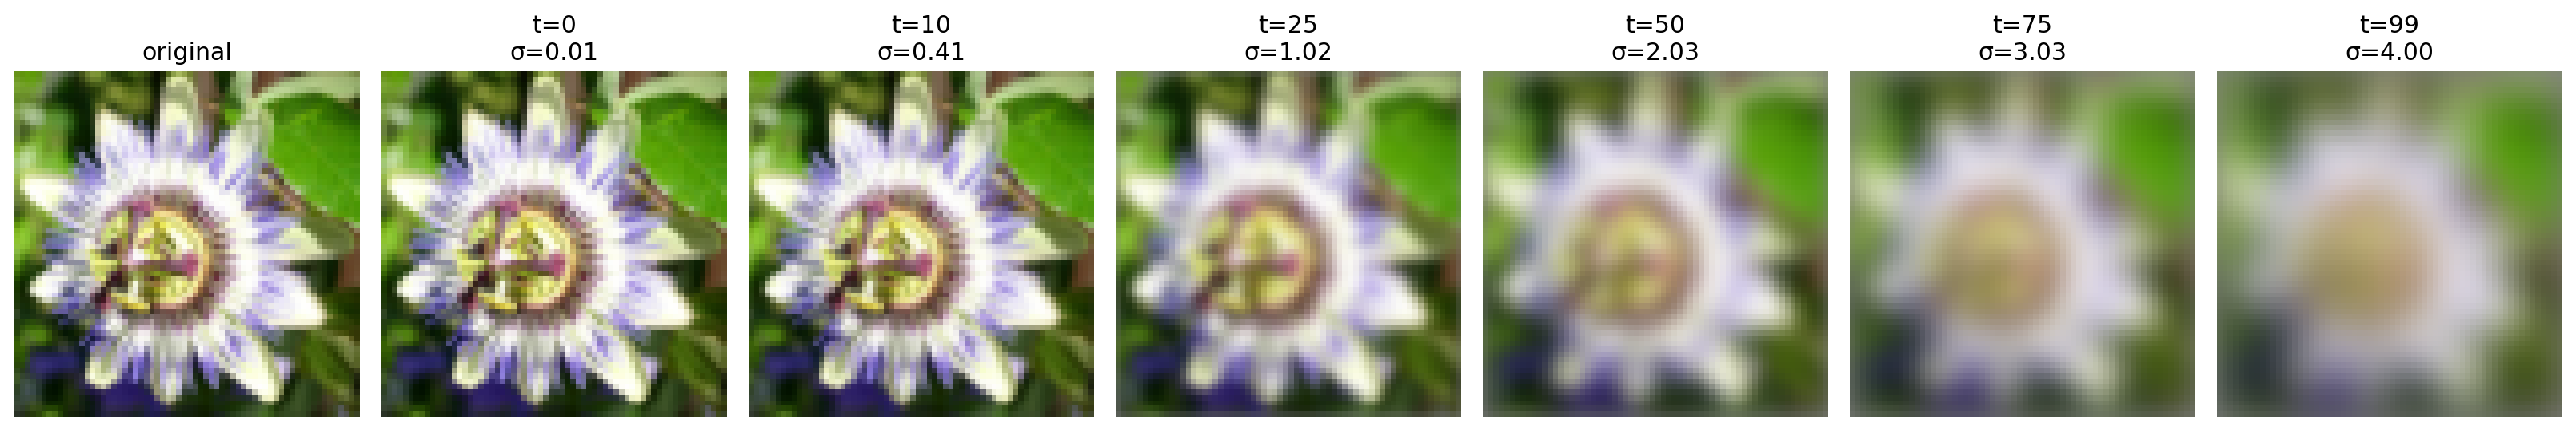
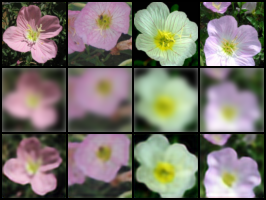
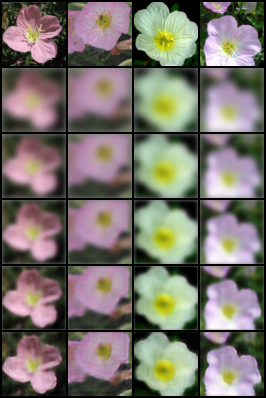

In [2]:
items = [
    {
        "title": "Blur Schedule Visualization",
        "file": "figure_blur_schedule.png",
        "caption": "Progressive deterministic blur used in the Cold Diffusion degradation process."
    },
    {
        "title": "Reconstruction Examples",
        "file": "figure_reconstruction_examples.png",
        "caption": "Representative reconstruction outputs on Oxford-102 Flowers using the trained model."
    },
    {
        "title": "Reverse Trajectory",
        "file": "figure_reverse_trajectory.png",
        "caption": "Step-by-step restoration from heavily blurred input toward clean reconstruction."
    }
]
render_cards(
    "4. Qualitative Results",
    "These figures summarize the restoration behavior of the proposed Cold Diffusion pipeline.",
    items,
    columns=2
)



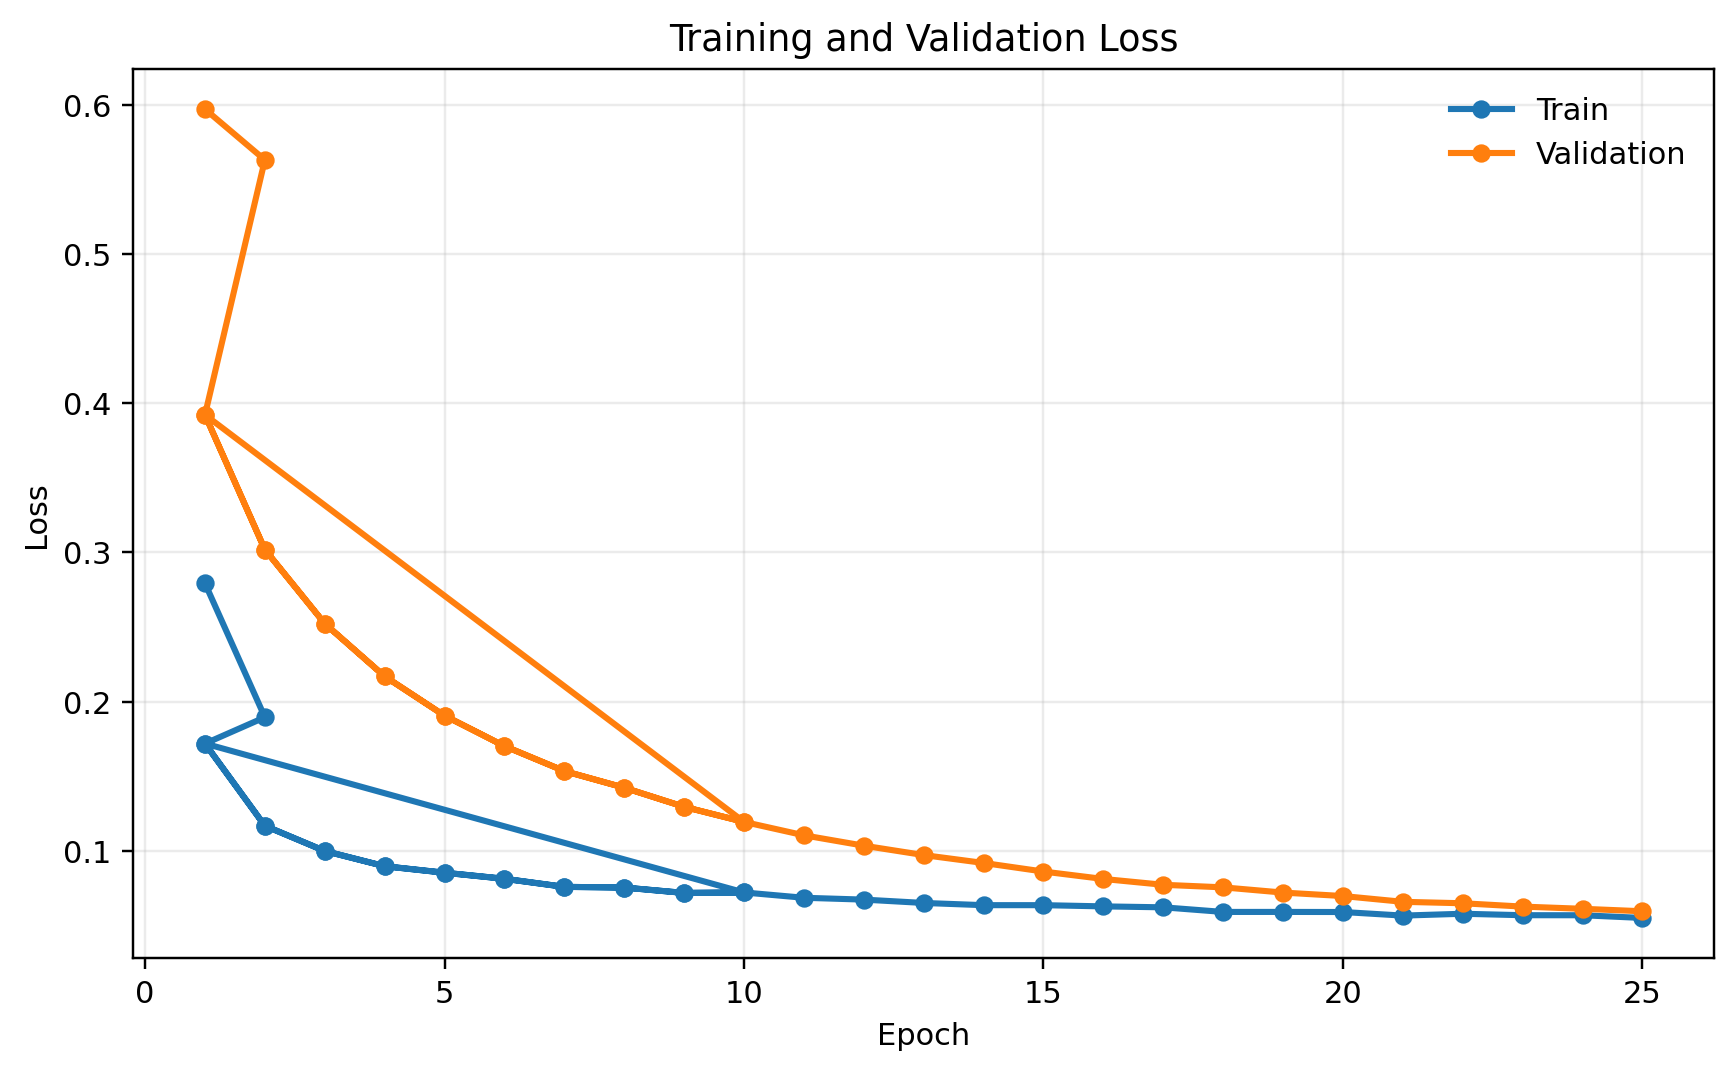
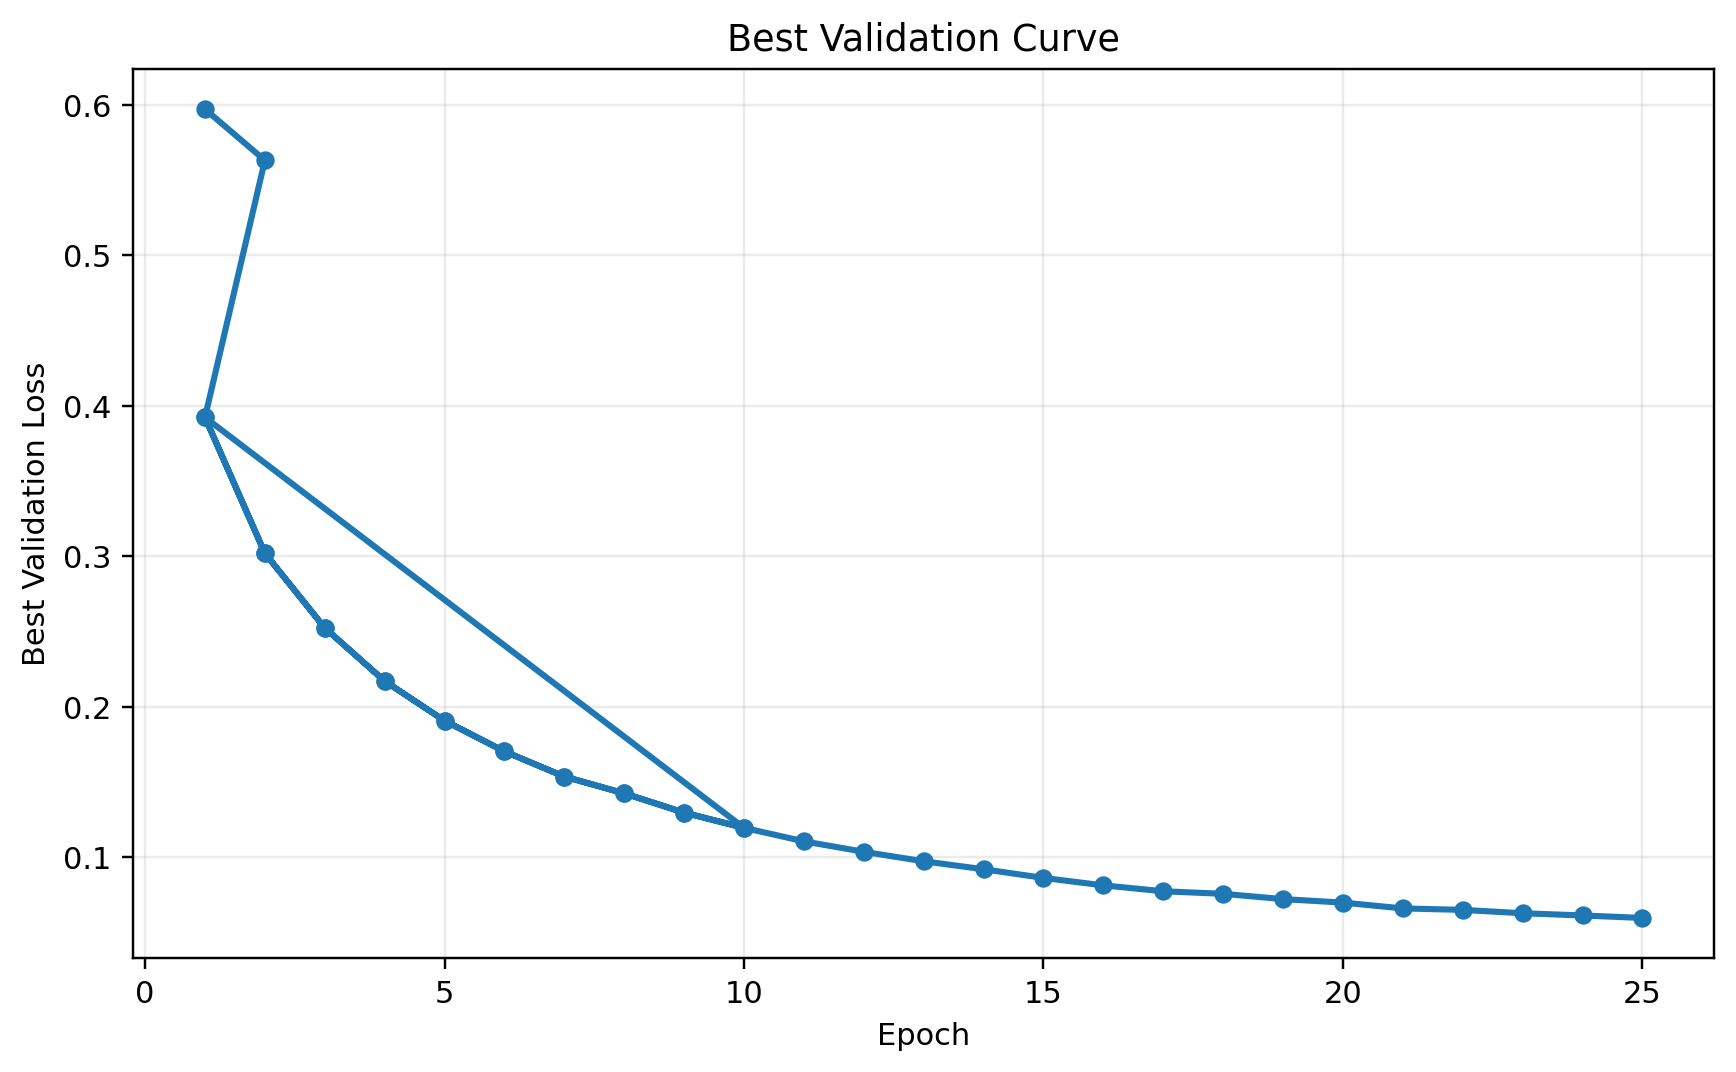
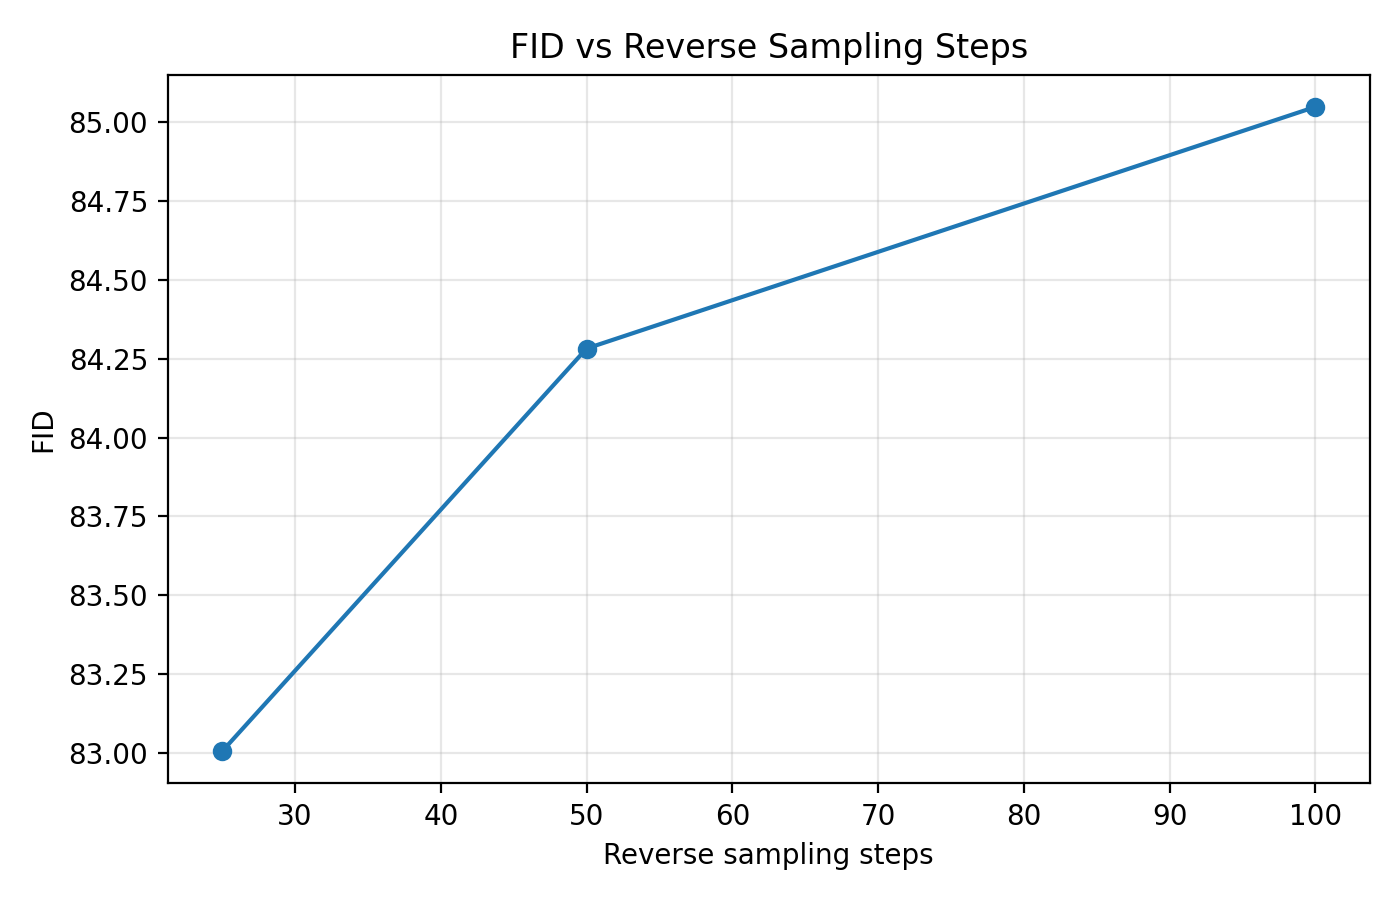
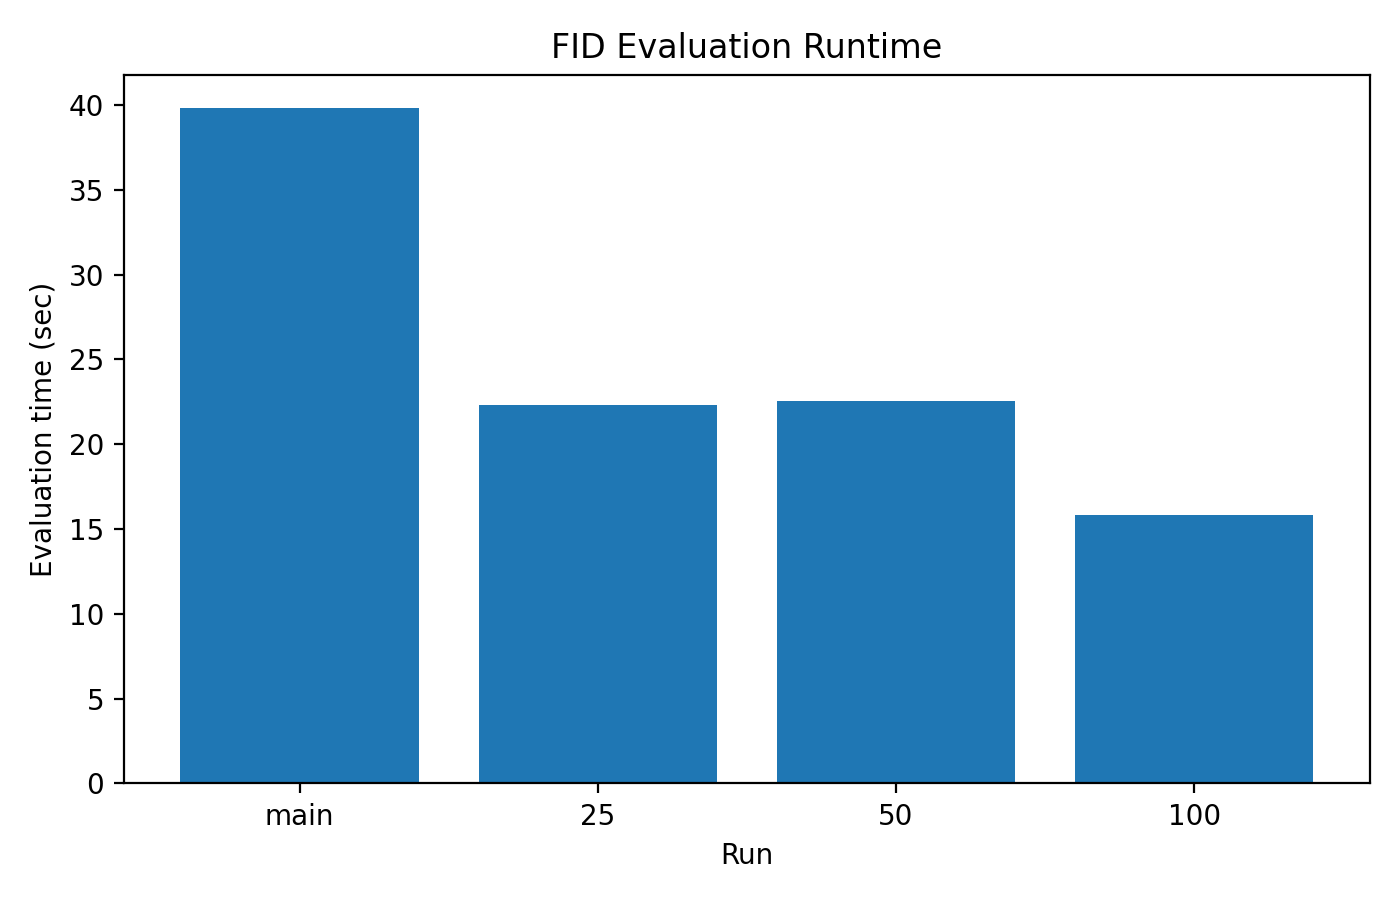

In [3]:
items = [
    {
        "title": "Training and Validation Loss",
        "file": "figure_loss_curves.png",
        "caption": "Optimization behavior across epochs for training and validation."
    },
    {
        "title": "Best Validation Curve",
        "file": "figure_best_val_curve.png",
        "caption": "Best validation loss achieved over the course of training."
    },
    {
        "title": "FID Ablation on Reverse Steps",
        "file": "figure_fid_ablation_steps.png",
        "caption": "Comparison of FID across 25, 50, and 100 reverse-step settings."
    },
    {
        "title": "FID Runtime Comparison",
        "file": "figure_fid_runtime.png",
        "caption": "Runtime trade-off for the evaluated reverse-step configurations."
    }
]
render_cards(
    "5. Quantitative Figures",
    "Quantitative plots highlighting convergence, evaluation quality, and runtime cost.",
    items,
    columns=2
)


In [4]:
render_table(
    "table_fid_ablation.csv",
    "6. Quantitative Results Table",
    "Rounded report-ready FID ablation results."
)


run,fid,num_real,num_fake,device,time_sec
main,85.049,1020.000,1020.000,cuda,39.801
25,83.005,1020.000,1020.000,cuda,22.294
50,84.282,1020.000,1020.000,cuda,22.574
100,85.049,1020.000,1020.000,cuda,15.809


In [5]:
summary_path = report_dir / "results_summary.txt"
if summary_path.exists():
    text = summary_path.read_text(encoding="utf-8")
    display(HTML(f'''
    <div style="max-width:1240px;margin:18px auto 0 auto;background:white;border:1px solid #e2e8f0;border-radius:18px;padding:18px 20px;box-shadow:0 10px 28px rgba(15,23,42,0.06);font-family:Arial,Helvetica,sans-serif;">
        <div style="font-size:24px;font-weight:900;color:#0f172a;margin-bottom:12px;">7. Results Summary</div>
        <pre style="margin:0;white-space:pre-wrap;font-family:Consolas,monospace;font-size:13px;line-height:1.75;color:#334155;">{text}</pre>
    </div>
    '''))


## 8. Discussion

The shorter reverse schedule achieved the best FID in the current restoration-based setting. This indicates that increasing the number of reverse updates did not necessarily improve final perceptual quality in this implementation.


## 9. Reproducibility

This notebook embeds local figures directly and resolves project paths automatically, which makes rendering reliable even if the working directory changes.
